In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [83]:
df= pd.read_csv('solar_leads_merged.csv')

In [84]:
model_data = df[
    [
        "distance_from_darab_km",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "lead_source",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman",
        "purchased"
    ]
].copy()

In [85]:
model_data.isna().sum()

distance_from_darab_km              0
property_type                       0
usage_purpose                      12
electricity_access                  0
lead_source                        12
required_appliances                 0
estimated_daily_energy_need_kwh     0
quoted_price_m_toman                0
purchased                           0
dtype: int64

In [86]:
model_data["usage_purpose"] = model_data["usage_purpose"].fillna(
    model_data["usage_purpose"].mode()[0]
)

model_data["lead_source"] = model_data["lead_source"].fillna(
    model_data["lead_source"].mode()[0]
)

In [87]:
x = model_data.drop("purchased", axis=1)
y = model_data["purchased"]

In [88]:
x_encoded = pd.get_dummies(x,columns=["property_type",
    "usage_purpose",
    "electricity_access",
    "lead_source",
    "required_appliances"],dtype=int)

In [90]:
from sklearn.model_selection import train_test_split


# split
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



In [91]:
log_model = LogisticRegression(max_iter=5000,  solver="liblinear",random_state=42)

log_model.fit(x_train, y_train)

LogisticRegression(max_iter=5000, random_state=42, solver='liblinear')

In [92]:
log_pred = log_model.predict(x_test)

In [93]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.70      0.53      0.60        36
           1       0.73      0.85      0.79        54

    accuracy                           0.72        90
   macro avg       0.72      0.69      0.69        90
weighted avg       0.72      0.72      0.71        90



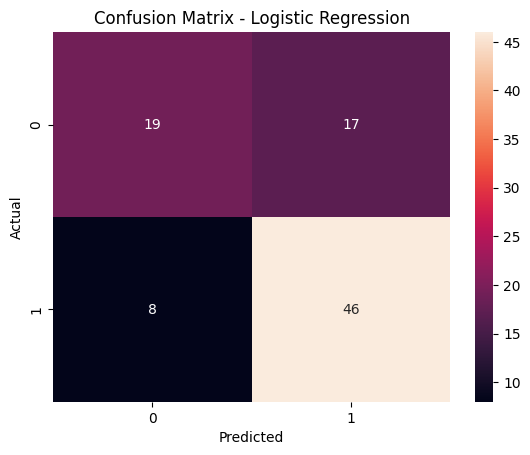

In [94]:
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [95]:
cm = confusion_matrix(y_test, log_pred)
cm

array([[19, 17],
       [ 8, 46]])

In [99]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [100]:
tree_pred = tree_model.predict(x_test)

In [101]:
accuracy_score(y_test, tree_pred)

0.6

In [102]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.50      0.61      0.55        36
           1       0.70      0.59      0.64        54

    accuracy                           0.60        90
   macro avg       0.60      0.60      0.59        90
weighted avg       0.62      0.60      0.60        90



In [103]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [106]:
rf_pred = rf_model.predict (x_test)

In [107]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.59      0.53      0.56        36
           1       0.71      0.76      0.73        54

    accuracy                           0.67        90
   macro avg       0.65      0.64      0.65        90
weighted avg       0.66      0.67      0.66        90



In [108]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7222222222222222
Decision Tree Accuracy: 0.6
Random Forest Accuracy: 0.6666666666666666


Logistic Regression was selected as the final model because it achieved the highest accuracy among the tested models. 

In [109]:
final_model = LogisticRegression(
    max_iter=5000,
    solver="liblinear",
    random_state=42
)

final_model.fit(x_encoded, y)

LogisticRegression(max_iter=5000, random_state=42, solver='liblinear')

In [110]:
purchase_probabilities = final_model.predict_proba(x_encoded)[:, 1]

In [111]:
df_scored = df.copy()

df_scored["purchase_probability"] = purchase_probabilities

In [112]:
df_scored["lead_score"] = df_scored["purchase_probability"] * 100
df_scored["lead_score"] = df_scored["lead_score"].round(1)

In [113]:
df_scored["priority_level"] = pd.cut(
    df_scored["lead_score"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [114]:
df_scored[
    [
        "lead_id",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman",
        "purchase_probability",
        "lead_score",
        "priority_level"
    ]
].head(10)

,lead_id,property_type,usage_purpose,electricity_access,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchase_probability,lead_score,priority_level
0,L0001,garden_house,mixed_use,none,"pump,lights",10.0,628.7,0.562716,56.3,Medium
1,L0002,rural_house,seasonal_garden,none,"lights,TV",2.5,151.0,0.492726,49.3,Medium
2,L0003,garden_house,mixed_use,none,"lights,fridge,TV",4.5,284.1,0.536800,53.7,Medium
3,L0004,garden_house,seasonal_garden,unstable,"lights,fridge",4.7,286.8,0.237420,23.7,Low
4,L0005,garden_house,mixed_use,unstable,"lights,fridge",5.1,282.2,0.488387,48.8,Medium
5,L0006,garden_house,seasonal_garden,unstable,"AC,fridge,lights",10.9,586.2,0.228697,22.9,Low
6,L0007,garden_house,mixed_use,unstable,"AC,fridge",9.1,378.0,0.294567,29.5,Low
7,L0008,farm,agriculture,unstable,"pump,fridge",11.1,761.7,0.809788,81.0,High
8,L0009,rural_house,seasonal_garden,none,"lights,TV",2.3,138.7,0.529022,52.9,Medium
9,L0010,garden_house,seasonal_garden,none,lights,1.3,96.5,0.193234,19.3,Low


In [115]:
top_leads = df_scored.sort_values("lead_score", ascending=False)

top_leads[
    [
        "lead_id",
        "village",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "required_appliances",
        "quoted_price_m_toman",
        "lead_score",
        "priority_level"
    ]
].head(20)

,lead_id,village,property_type,usage_purpose,electricity_access,required_appliances,quoted_price_m_toman,lead_score,priority_level
52,L0053,Banouj,farm,agriculture,none,"pump,AC",795.0,93.9,High
41,L0042,Pasakhan,farm,agriculture,none,"pump,AC",749.3,93.4,High
136,L0137,Shahanan,farm,agriculture,none,"pump,AC",761.5,92.6,High
91,L0092,Khosouyeh,farm,agriculture,none,"pump,AC",817.2,91.2,High
15,L0016,Rostaq,farm,agriculture,none,"pump,AC",723.2,90.5,High
54,L0055,Jamsi,farm,mixed_use,unstable,"pump,AC",669.0,90.2,High
130,L0131,Banouj,farm,agriculture,none,"pump,AC",718.7,89.4,High
68,L0069,Banouj,farm,agriculture,none,"pump,AC",741.9,88.8,High
287,L0288,Nidshahr,farm,agriculture,none,pump,591.5,88.1,High
17,L0018,Jamsi,farm,agriculture,none,pump,621.0,87.8,High


In [116]:
df_scored["priority_level"].value_counts()

priority_level
High      119
Medium    118
Low        63
Name: count, dtype: int64

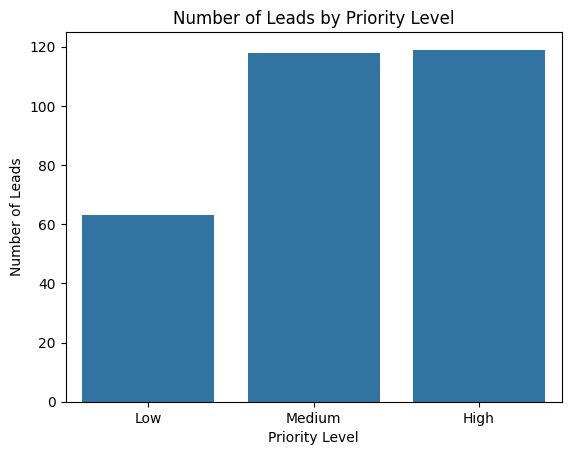

In [117]:
sns.countplot(data=df_scored, x="priority_level")

plt.title("Number of Leads by Priority Level")
plt.xlabel("Priority Level")
plt.ylabel("Number of Leads")
plt.show()

In [118]:
df_scored.groupby("priority_level")["purchased"].mean() * 100

C:\Users\azarakhsh\AppData\Local\Temp\ipykernel_25340\1191550598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scored.groupby("priority_level")["purchased"].mean() * 100


priority_level
Low       26.984127
Medium    55.084746
High      82.352941
Name: purchased, dtype: float64

In [121]:
df_scored.to_csv('solar_leads_scored.csv')

In [122]:
df_scored.head(5)

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased,purchase_probability,lead_score,priority_level
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral,"pump,lights",10.0,628.7,1,0.562716,56.3,Medium
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral,"lights,TV",2.5,151.0,1,0.492726,49.3,Medium
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral,"lights,fridge,TV",4.5,284.1,0,0.536800,53.7,Medium
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad,"lights,fridge",4.7,286.8,0,0.237420,23.7,Low
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram,"lights,fridge",5.1,282.2,1,0.488387,48.8,Medium


In [123]:
feature_importance = pd.DataFrame({
    "feature": x_encoded.columns,
    "coefficient": final_model.coef_[0]
})

feature_importance = feature_importance.sort_values("coefficient", ascending=False)

feature_importance.head(15)

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [124]:
feature_importance = feature_importance.sort_values("coefficient", ascending=False)

In [125]:
feature_importance

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [53]:
feature_importance.head(15)

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [126]:
feature_importance.tail(15)

,feature,coefficient
5,property_type_rural_house,0.011836
2,quoted_price_m_toman,0.001120
11,electricity_access_unstable,-0.006057
17,"required_appliances_AC,fridge,lights",-0.006697
0,distance_from_darab_km,-0.007012
8,usage_purpose_primary_residence,-0.041572
1,estimated_daily_energy_need_kwh,-0.076710
24,"required_appliances_pump,fridge",-0.177614
25,"required_appliances_pump,lights",-0.282209
13,lead_source_local_ad,-0.291896


## Purchase Prediction Interpretation

In this notebook, three classification models were developed and compared to estimate customer purchase likelihood: Logistic Regression, Decision Tree, and Random Forest. The dataset was split into training and testing sets using a 70/30 split, and `stratify=y` was used to keep the proportion of purchased and non-purchased customers similar in both sets.

Logistic Regression achieved the best overall performance, with a test accuracy of about 72.2%. It was selected as the final model because it provided a good balance between predictive performance and interpretability. The model was trained using `solver="liblinear"`, which is suitable for binary classification problems and small datasets. This fits the structure of this project, where each lead either purchased or did not purchase the solar system.

Decision Tree and Random Forest were also tested, but they achieved lower accuracy than Logistic Regression on the test set. Therefore, Logistic Regression was used to generate purchase probabilities for all leads.

The predicted probabilities were converted into lead scores from 0 to 100 and grouped into Low, Medium, and High follow-up levels. These scores should not be interpreted as a lead rejection system. Instead, they are used as a decision-support signal to help the company adapt its sales communication based on customer profile and estimated purchase likelihood.

Overall, the model supports customer understanding and sales decision-making while keeping human judgment central to the process.
